In [37]:
import pandas as pd
import numpy as np
import statsmodels.api as sm


In [38]:
df=pd.read_csv(r'INPUT.csv')
df.head()

,DateTime,Date,Heure,Valeur,SPOT,MA,BIOMASS,FOSSIL_GAS,FOSSIL_HARD_COAL,FOSSIL_OIL,HYDRO_PUMPED_STORAGE,HYDRO_RUN_OF_RIVER,HYDRO_WATER_RESERVOIR,NUCLEAR,SOLAR,WASTE,WIND_ONSHORE,conso
0,2024-01-01,00:00:00,2024-01-01,00:00:00,19.49,197.27,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,52800.0
1,2024-01-01,00:30:00,2024-01-01,00:00:00,19.49,206.63,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,53000.0
2,2024-01-01,01:00:00,2024-01-01,01:00:00,16.12,23.62,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,47200.0
3,2024-01-01,01:30:00,2024-01-01,01:00:00,16.12,56.66,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,48100.0
4,2024-01-01,02:00:00,2024-01-01,02:00:00,0.06,10.68,171.5,893.5,8.0,95.0,-842.5,2459.0,502.5,18660.0,0.0,43.5,6894.5,49800.0


In [39]:
df['DateTime']=pd.to_datetime(df['DateTime'])
df['Date']=pd.to_datetime(df['Date'])

C:\Users\adamh\AppData\Local\Temp\ipykernel_8048\3055581797.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date']=pd.to_datetime(df['Date'])


In [40]:
df['Minute']=df['Date'].dt.minute
df['Heure']=df['Date'].dt.hour
df['Jour']=df['DateTime'].dt.day
df['Mois']=df['DateTime'].dt.month
df['Annee']=df['DateTime'].dt.year

In [41]:
df.head()

,DateTime,Date,Heure,Valeur,SPOT,MA,BIOMASS,FOSSIL_GAS,FOSSIL_HARD_COAL,FOSSIL_OIL,...,HYDRO_WATER_RESERVOIR,NUCLEAR,SOLAR,WASTE,WIND_ONSHORE,conso,Minute,Jour,Mois,Annee
0,2024-01-01,2025-08-03 00:00:00,0,00:00:00,19.49,197.27,171.5,905.0,7.5,81.0,...,740.5,20193.5,112.5,43.5,7199.5,52800.0,0,1,1,2024
1,2024-01-01,2025-08-03 00:30:00,0,00:00:00,19.49,206.63,171.5,905.0,7.5,81.0,...,740.5,20193.5,112.5,43.5,7199.5,53000.0,30,1,1,2024
2,2024-01-01,2025-08-03 01:00:00,1,01:00:00,16.12,23.62,171.5,920.0,8.0,95.5,...,641.0,18764.0,0.0,41.5,7078.5,47200.0,0,1,1,2024
3,2024-01-01,2025-08-03 01:30:00,1,01:00:00,16.12,56.66,171.5,920.0,8.0,95.5,...,641.0,18764.0,0.0,41.5,7078.5,48100.0,30,1,1,2024
4,2024-01-01,2025-08-03 02:00:00,2,02:00:00,0.06,10.68,171.5,893.5,8.0,95.0,...,502.5,18660.0,0.0,43.5,6894.5,49800.0,0,1,1,2024


In [42]:
df=df.drop(columns=['DateTime','Valeur','Date'])

In [43]:
df.head()

,Heure,SPOT,MA,BIOMASS,FOSSIL_GAS,FOSSIL_HARD_COAL,FOSSIL_OIL,HYDRO_PUMPED_STORAGE,HYDRO_RUN_OF_RIVER,HYDRO_WATER_RESERVOIR,NUCLEAR,SOLAR,WASTE,WIND_ONSHORE,conso,Minute,Jour,Mois,Annee
0,0,19.49,197.27,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,52800.0,0,1,1,2024
1,0,19.49,206.63,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,53000.0,30,1,1,2024
2,1,16.12,23.62,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,47200.0,0,1,1,2024
3,1,16.12,56.66,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,48100.0,30,1,1,2024
4,2,0.06,10.68,171.5,893.5,8.0,95.0,-842.5,2459.0,502.5,18660.0,0.0,43.5,6894.5,49800.0,0,1,1,2024


In [44]:
df=df[['Heure','Minute','Jour','Mois','Annee']+[col for col in df.columns if col not in ['Heure','Minute','Jour','Mois','Annee']]]
df.head()

,Heure,Minute,Jour,Mois,Annee,SPOT,MA,BIOMASS,FOSSIL_GAS,FOSSIL_HARD_COAL,FOSSIL_OIL,HYDRO_PUMPED_STORAGE,HYDRO_RUN_OF_RIVER,HYDRO_WATER_RESERVOIR,NUCLEAR,SOLAR,WASTE,WIND_ONSHORE,conso
0,0,0,1,1,2024,19.49,197.27,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,52800.0
1,0,30,1,1,2024,19.49,206.63,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,53000.0
2,1,0,1,1,2024,16.12,23.62,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,47200.0
3,1,30,1,1,2024,16.12,56.66,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,48100.0
4,2,0,1,1,2024,0.06,10.68,171.5,893.5,8.0,95.0,-842.5,2459.0,502.5,18660.0,0.0,43.5,6894.5,49800.0


normalisation

In [45]:
df=df.fillna(0)

In [46]:
Y=df['MA']
X=df[[col for col in df.columns if col!='MA']]

In [47]:
X.isna().sum()

Heure                    0
Minute                   0
Jour                     0
Mois                     0
Annee                    0
SPOT                     0
BIOMASS                  0
FOSSIL_GAS               0
FOSSIL_HARD_COAL         0
FOSSIL_OIL               0
HYDRO_PUMPED_STORAGE     0
HYDRO_RUN_OF_RIVER       0
HYDRO_WATER_RESERVOIR    0
NUCLEAR                  0
SOLAR                    0
WASTE                    0
WIND_ONSHORE             0
conso                    0
dtype: int64

In [48]:
Y.isna().sum()

0

In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)  # Scale only X

FNN

In [50]:
import tensorflow as tf

def create_feedworward_network_model(input_dim,
                                     hidden_layers_sizes,
                                     layers_activation,
                                     output_dim,
                                     output_activation):
   '''
   Create a simple feedforward neural network model using Tensorflow/Keras APIs taking a vector as input
   Inputs:
   input_dim: input dimention
   hidden_layers_sizes: list specifying layers sizes. Its length is the number of hidden layers
   layers_activation: hidden layers activation function ('relu','sigmoid','tanh',... )
   output_dim: output dimension
   output_activation: output activation function
   	'linear' for regression
   	'sigmoid' for binary classification
   	'softmax': for multi class classification
   Outputs:
   ffn_model: feedfoward network model
   '''
   nb_hidden_layers=len(hidden_layers_sizes)
   inputs = tf.keras.Input(shape=(input_dim,))
   for n in range(nb_hidden_layers):
      if n==0:
         layer_output=tf.keras.layers.Dense(hidden_layers_sizes[n],activation=layers_activation)(inputs)
      else:
         layer_output=tf.keras.layers.Dense(hidden_layers_sizes[n], activation=layers_activation)(layer_output)
   outputs=tf.keras.layers.Dense(output_dim,activation=output_activation)(layer_output)
   ffn_model = tf.keras.Model(inputs,outputs,name='feed_forward_network')
   return ffn_model

In [51]:
# import tensorflow as tf
# from sklearn.model_selection import train_test_split


# x_train, x_val, y_train, y_val = train_test_split(
#     X, Y,
#     test_size=0.2,       # 20% des données pour validation, 80% pour entraînement
#     random_state=42,     # pour reproductibilité
#     shuffle=True         # bien mélanger avant de séparer
# )

In [52]:
split_index = int(len(X) * 0.8)
x_train, x_val = X[:split_index], X[split_index:]
y_train, y_val = Y[:split_index], Y[split_index:]


In [53]:
x_train.shape

(14035, 18)

In [54]:
# y_train.shape[1]

In [55]:
from sklearn.model_selection import KFold
from itertools import product
from sklearn.metrics import mean_absolute_error


# Paramètres des modèles
hidden_layers_options = [[256], [128], [256, 128]]  # Différentes architectures testées
activation_functions = ['sigmoid', 'relu', 'tanh']  # Différentes fonctions d'activation
performances=1000
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for hidden_layers_sizes, layers_activation in product(hidden_layers_options, activation_functions):

    print(f"Architecture: {hidden_layers_sizes}, Activation: {layers_activation}")
    input_dim=x_train.shape[1]
    # hidden_layers_sizes=[100,100]
    # layers_activation='relu'
    output_dim=1
    output_activation='linear'

    model=create_feedworward_network_model(input_dim,
                                        hidden_layers_sizes,
                                        layers_activation,
                                        output_dim,
                                        output_activation)

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(optimizer=optimizer,loss='mean_squared_error',metrics=['mae'])

    model.fit(x_train,y_train,epochs=1,batch_size=16,
                        validation_data=(x_val,y_val),
                        shuffle=True)
    y_pred=model.predict(x_val)
    acc = mean_absolute_error(y_val, y_pred)
    scores.append([acc,hidden_layers_sizes, layers_activation])
    print(acc)
    if acc<=performances:
        performances=acc
        result=performances,hidden_layers_sizes,layers_activation
        print(result)

result

Architecture: [256], Activation: sigmoid
878/878 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 18722.6582 - mae: 83.0109 - val_loss: 9558.5078 - val_mae: 79.4416
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step
79.44155310443543
(79.44155310443543, [256], 'sigmoid')
Architecture: [256], Activation: relu
878/878 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 16747.8301 - mae: 81.4258 - val_loss: 10397.0693 - val_mae: 83.9321
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step
83.93207435736463
Architecture: [256], Activation: tanh
878/878 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 21241.3066 - mae: 84.4107 - val_loss: 11744.1045 - val_mae: 90.8970
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step
90.89695589221391
Architecture: [128], Activation: sigmoid
878/878 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 18198.7578 - mae: 82.4886 - val_loss: 10106.4980 - val_mae: 82.3414
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step
82.34138730873441
Architecture: [128], Activation: relu
878/878 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 18496.

(57.72340144292484, [256, 128], 'relu')

In [56]:
scores

[[79.44155310443543, [256], 'sigmoid'],
 [83.93207435736463, [256], 'relu'],
 [90.89695589221391, [256], 'tanh'],
 [82.34138730873441, [128], 'sigmoid'],
 [84.42664638309883, [128], 'relu'],
 [88.55955326478522, [128], 'tanh'],
 [74.9978158689245, [256, 128], 'sigmoid'],
 [57.72340144292484, [256, 128], 'relu'],
 [107.70601565227595, [256, 128], 'tanh']]

RNN

Modifier La struture des données, j'ai besoin de liste de liste où chaque nouvelle liste est un timestemp en plus

In [57]:
len(x_train)

14035

In [58]:
len(y_train)

14035

In [59]:
timesteps = 24
x_train_rnn, y_train_rnn = [], []
x_val_rnn, y_val_rnn = [], []

for i in range(len(x_train) - timesteps):
    x_train_rnn.append(x_train[i:i+timesteps])
    y_train_rnn.append(y_train.iloc[i+timesteps])  # valeur juste après la séquence

for i in range(len(x_val) - timesteps):
    x_val_rnn.append(x_val[i:i+timesteps])
    y_val_rnn.append(y_val.iloc[i+timesteps])

x_train_rnn = np.array(x_train_rnn)
y_train_rnn = np.array(y_train_rnn).reshape(-1, 1)
x_val_rnn = np.array(x_val_rnn)
y_val_rnn = np.array(y_val_rnn).reshape(-1, 1)


In [60]:
x_train=x_train_rnn
x_val=x_val_rnn
y_train=y_train_rnn
y_val=y_val_rnn

In [61]:
x_train

array([[[-1.66132477, -0.99863295, -1.67464054, ..., -1.60857949,
          2.67859378,  0.39610076],
        [-1.66132477,  1.00136893, -1.67464054, ..., -1.60857949,
          2.67859378,  0.41540118],
        [-1.51686175, -0.99863295, -1.67464054, ..., -1.66526314,
          2.61326635, -0.14431107],
        ...,
        [-0.21669454,  1.00136893, -1.67464054, ..., -1.5093831 ,
          1.63281509,  2.20069027],
        [-0.07223151, -0.99863295, -1.67464054, ..., -1.48104128,
          1.47732502,  1.93048435],
        [-0.07223151,  1.00136893, -1.67464054, ..., -1.48104128,
          1.47732502,  2.03663668]],

       [[-1.66132477,  1.00136893, -1.67464054, ..., -1.60857949,
          2.67859378,  0.41540118],
        [-1.51686175, -0.99863295, -1.67464054, ..., -1.66526314,
          2.61326635, -0.14431107],
        [-1.51686175,  1.00136893, -1.67464054, ..., -1.66526314,
          2.61326635, -0.05745917],
        ...,
        [-0.07223151, -0.99863295, -1.67464054, ..., -

In [62]:
def create_rnn_network_model(input_dim,
                              timesteps,
                              hidden_layers_sizes,
                              layers_activation,
                              output_dim,
                              output_activation):
    '''
    Create a simple RNN model using Tensorflow/Keras APIs taking a sequence as input
    Inputs:
    input_dim: feature dimension at each timestep
    timesteps: number of timesteps in the input sequence
    hidden_layers_sizes: list specifying RNN layers sizes
    layers_activation: activation function for RNN layers ('tanh', 'relu', ...)
    output_dim: output dimension
    output_activation: output activation function
        'linear' for regression
        'sigmoid' for binary classification
        'softmax' for multi-class classification
    Outputs:
    rnn_model: RNN model
    '''
    nb_hidden_layers = len(hidden_layers_sizes)
    inputs = tf.keras.Input(shape=(timesteps, input_dim))
    for n in range(nb_hidden_layers):
        return_seq = n < nb_hidden_layers - 1
        if n == 0:
            layer_output = tf.keras.layers.SimpleRNN(hidden_layers_sizes[n],
                                                     activation=layers_activation,
                                                     return_sequences=return_seq)(inputs)
        else:
            layer_output = tf.keras.layers.SimpleRNN(hidden_layers_sizes[n],
                                                     activation=layers_activation,
                                                     return_sequences=return_seq)(layer_output)
    outputs = tf.keras.layers.Dense(output_dim, activation=output_activation)(layer_output)
    rnn_model = tf.keras.Model(inputs, outputs, name='rnn_network')
    return rnn_model


In [63]:
from sklearn.model_selection import KFold
from itertools import product
from sklearn.metrics import mean_absolute_error


# Paramètres des modèles
hidden_layers_options = [[256], [128], [256, 128]]  # Différentes architectures testées
activation_functions = ['sigmoid', 'relu', 'tanh']  # Différentes fonctions d'activation
performances=1000
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []
timesteps=int(48),


for hidden_layers_sizes, layers_activation in product(hidden_layers_options, activation_functions):

    print(f"Architecture: {hidden_layers_sizes}, Activation: {layers_activation}")
    # hidden_layers_sizes=[100,100]
    # layers_activation='relu'
    timesteps = x_train.shape[1]
    input_dim = x_train.shape[2]
    output_dim=1
    output_activation='linear'

    model=create_rnn_network_model(input_dim,timesteps,
                                        hidden_layers_sizes,
                                        layers_activation,
                                        output_dim,
                                        output_activation)

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(optimizer=optimizer,loss='mean_squared_error',metrics=['mae'])

    model.fit(x_train,y_train,epochs=1,batch_size=16,
                        validation_data=(x_val,y_val),
                        shuffle=True)
    y_pred=model.predict(x_val)
    acc = mean_absolute_error(y_val, y_pred)
    scores.append([acc,hidden_layers_sizes, layers_activation])
    print(acc)
    if acc<=performances:
        performances=acc
        result=performances,hidden_layers_sizes,layers_activation
        print(result)

result

Architecture: [256], Activation: sigmoid
876/876 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 20003.8770 - mae: 78.7853 - val_loss: 7515.0566 - val_mae: 67.9491
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
67.94910903711742
(67.94910903711742, [256], 'sigmoid')
Architecture: [256], Activation: relu
876/876 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 17109.4082 - mae: 68.7220 - val_loss: 4155.2021 - val_mae: 46.2981
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
46.298137392172684
(46.298137392172684, [256], 'relu')
Architecture: [256], Activation: tanh
876/876 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 17554.9277 - mae: 78.2481 - val_loss: 17017.7363 - val_mae: 115.6695
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
115.6695125178114
Architecture: [128], Activation: sigmoid
876/876 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 20338.8398 - mae: 80.7382 - val_loss: 8824.3877 - val_mae: 75.3825
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
75.38253743663991
Architecture: [128], Activation: relu
876/876 ━━━━━━━━━━━━━━━━━━━

(46.298137392172684, [256], 'relu')

LSTM

In [64]:

def create_lstm_network_model(input_dim,
                              timesteps,
                              hidden_layers_sizes,
                              layers_activation,
                              output_dim,
                              output_activation):
    '''
    Create a simple LSTM model using Tensorflow/Keras APIs taking a sequence as input
    Inputs:
    input_dim: feature dimension at each timestep
    timesteps: number of timesteps in the input sequence
    hidden_layers_sizes: list specifying LSTM layers sizes
    layers_activation: activation function for LSTM layers ('tanh', 'relu', ...)
    output_dim: output dimension
    output_activation: output activation function
        'linear' for regression
        'sigmoid' for binary classification
        'softmax' for multi-class classification
    Outputs:
    lstm_model: LSTM model
    '''
    nb_hidden_layers = len(hidden_layers_sizes)
    inputs = tf.keras.Input(shape=(timesteps, input_dim))
    for n in range(nb_hidden_layers):
        return_seq = n < nb_hidden_layers - 1  # Only return sequences except for last LSTM
        if n == 0:
            layer_output = tf.keras.layers.LSTM(hidden_layers_sizes[n],
                                                activation=layers_activation,
                                                return_sequences=return_seq)(inputs)
        else:
            layer_output = tf.keras.layers.LSTM(hidden_layers_sizes[n],
                                                activation=layers_activation,
                                                return_sequences=return_seq)(layer_output)
    outputs = tf.keras.layers.Dense(output_dim, activation=output_activation)(layer_output)
    lstm_model = tf.keras.Model(inputs, outputs, name='lstm_network')
    return lstm_model


In [65]:
from sklearn.model_selection import KFold
from itertools import product
from sklearn.metrics import mean_absolute_error


# Paramètres des modèles
hidden_layers_options = [[256], [128], [256, 128]]  # Différentes architectures testées
activation_functions = ['sigmoid', 'relu', 'tanh']  # Différentes fonctions d'activation
performances=1000
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []
timesteps=int(48),


for hidden_layers_sizes, layers_activation in product(hidden_layers_options, activation_functions):

    print(f"Architecture: {hidden_layers_sizes}, Activation: {layers_activation}")
    # hidden_layers_sizes=[100,100]
    # layers_activation='relu'
    timesteps = x_train.shape[1]
    input_dim = x_train.shape[2]
    output_dim=1
    output_activation='linear'

    model=create_lstm_network_model(input_dim,timesteps,
                                        hidden_layers_sizes,
                                        layers_activation,
                                        output_dim,
                                        output_activation)

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(optimizer=optimizer,loss='mean_squared_error',metrics=['mae'])

    model.fit(x_train,y_train,epochs=1,batch_size=16,
                        validation_data=(x_val,y_val),
                        shuffle=True)
    y_pred=model.predict(x_val)
    acc = mean_absolute_error(y_val, y_pred)
    scores.append([acc,hidden_layers_sizes, layers_activation])
    print(acc)
    if acc<=performances:
        performances=acc
        result=performances,hidden_layers_sizes,layers_activation
        print(result)

result

Architecture: [256], Activation: sigmoid
876/876 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 21819.8184 - mae: 79.3430 - val_loss: 7474.9326 - val_mae: 67.7126
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
67.71253827705547
(67.71253827705547, [256], 'sigmoid')
Architecture: [256], Activation: relu
876/876 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 17712.7617 - mae: 73.4951 - val_loss: 4221.9058 - val_mae: 45.8437
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
45.84368247331267
(45.84368247331267, [256], 'relu')
Architecture: [256], Activation: tanh
876/876 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 21067.4902 - mae: 77.1393 - val_loss: 8849.2383 - val_mae: 73.7704
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
73.77043540008013
Architecture: [128], Activation: sigmoid
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 20790.4980 - mae: 82.4281 - val_loss: 8941.1230 - val_mae: 76.0210
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
76.02102529143194
Architecture: [128], Activation: relu
876/876 ━━━━━━━━━━━━━━━━━

(43.99854088724977, [256, 128], 'relu')

SA_LSTM

In [66]:
from tensorflow.keras.layers import Attention, Dense, LayerNormalization

def create_sa_lstm_network_model(input_dim, timesteps, hidden_layers_sizes, layers_activation,
                                 output_dim, output_activation):
    inputs = tf.keras.Input(shape=(timesteps, input_dim))
    x = inputs
    for i, units in enumerate(hidden_layers_sizes):
        x = tf.keras.layers.LSTM(units, activation=layers_activation, return_sequences=True)(x)
    
    # Self-Attention
    attention = tf.keras.layers.Attention()([x, x])
    attention = tf.keras.layers.LayerNormalization()(attention)  # Optional, helps with training stability
    x = tf.keras.layers.GlobalAveragePooling1D()(attention)

    outputs = tf.keras.layers.Dense(output_dim, activation=output_activation)(x)
    return tf.keras.Model(inputs, outputs, name='SA_LSTM_model')


In [74]:
from sklearn.model_selection import KFold
from itertools import product
from sklearn.metrics import mean_absolute_error


# Paramètres des modèles
hidden_layers_options = [[256], [128], [256, 128]]  # Différentes architectures testées
activation_functions = ['sigmoid', 'relu', 'tanh']  # Différentes fonctions d'activation
performances=1000
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []
timesteps=int(48),


for hidden_layers_sizes, layers_activation in product(hidden_layers_options, activation_functions):

    print(f"Architecture: {hidden_layers_sizes}, Activation: {layers_activation}")
    # hidden_layers_sizes=[100,100]
    # layers_activation='relu'
    timesteps = x_train.shape[1]
    input_dim = x_train.shape[2]
    output_dim=1
    output_activation='linear'

    model=create_sa_lstm_network_model(input_dim,timesteps,
                                        hidden_layers_sizes,
                                        layers_activation,
                                        output_dim,
                                        output_activation)

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(optimizer=optimizer,loss='mean_squared_error',metrics=['mae'])

    model.fit(x_train,y_train,epochs=1,batch_size=16,
                        validation_data=(x_val,y_val),
                        shuffle=True)
    y_pred=model.predict(x_val)
    acc = mean_absolute_error(y_val, y_pred)
    scores.append([acc,hidden_layers_sizes, layers_activation])
    print(acc)
    if acc<=performances:
        performances=acc
        result=performances,hidden_layers_sizes,layers_activation
        print(result)

result

Architecture: [256], Activation: sigmoid


ValueError: Attention layer must be called on a list of inputs, namely [query, value] or [query, value, key]. Received: inputs=(None, 24, 256).

BISA-LSTM

In [68]:
def create_bisa_lstm_network_model(input_dim, timesteps, hidden_layers_sizes, layers_activation,
                                   output_dim, output_activation):
    inputs = tf.keras.Input(shape=(timesteps, input_dim))
    x = inputs
    for i, units in enumerate(hidden_layers_sizes):
        x = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(units, activation=layers_activation, return_sequences=True)
        )(x)

    # Self-Attention
    attention = tf.keras.layers.Attention()([x, x])
    attention = tf.keras.layers.LayerNormalization()(attention)
    x = tf.keras.layers.GlobalAveragePooling1D()(attention)

    outputs = tf.keras.layers.Dense(output_dim, activation=output_activation)(x)
    return tf.keras.Model(inputs, outputs, name='BiSA_LSTM_model')


In [69]:
from sklearn.model_selection import KFold
from itertools import product
from sklearn.metrics import mean_absolute_error


# Paramètres des modèles
hidden_layers_options = [[256], [128], [256, 128]]  # Différentes architectures testées
activation_functions = ['sigmoid', 'relu', 'tanh']  # Différentes fonctions d'activation
performances=1000
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []
timesteps=int(48),


for hidden_layers_sizes, layers_activation in product(hidden_layers_options, activation_functions):

    print(f"Architecture: {hidden_layers_sizes}, Activation: {layers_activation}")
    # hidden_layers_sizes=[100,100]
    # layers_activation='relu'
    timesteps = x_train.shape[1]
    input_dim = x_train.shape[2]
    output_dim=1
    output_activation='linear'

    model=create_bisa_lstm_network_model(input_dim,timesteps,
                                        hidden_layers_sizes,
                                        layers_activation,
                                        output_dim,
                                        output_activation)

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(optimizer=optimizer,loss='mean_squared_error',metrics=['mae'])

    model.fit(x_train,y_train,epochs=1,batch_size=16,
                        validation_data=(x_val,y_val),
                        shuffle=True)
    y_pred=model.predict(x_val)
    acc = mean_absolute_error(y_val, y_pred)
    scores.append([acc,hidden_layers_sizes, layers_activation])
    print(acc)
    if acc<=performances:
        performances=acc
        result=performances,hidden_layers_sizes,layers_activation
        print(result)

result

Architecture: [256], Activation: sigmoid
876/876 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 13159.8936 - mae: 67.4079 - val_loss: 4137.8760 - val_mae: 45.0044
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
45.00437352600535
(45.00437352600535, [256], 'sigmoid')
Architecture: [256], Activation: relu
876/876 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 17463.6680 - mae: 71.1979 - val_loss: 4696.1133 - val_mae: 49.2807
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
49.28066405772752
Architecture: [256], Activation: tanh
876/876 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 16478.0117 - mae: 72.0973 - val_loss: 7563.6621 - val_mae: 64.3111
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
64.31108897524192
Architecture: [128], Activation: sigmoid
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 19276.1895 - mae: 74.3481 - val_loss: 5500.6665 - val_mae: 55.1834
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
55.18338504277891
Architecture: [128], Activation: relu
876/876 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 17866.

(45.00437352600535, [256], 'sigmoid')

In [70]:
timesteps

24

### Run form here Part 2

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf


Preparer data

In [11]:
df=pd.read_csv(r'INPUT.csv')
df['DateTime']=pd.to_datetime(df['DateTime'])
df['Date']=pd.to_datetime(df['Date'])
df['Minute']=df['Date'].dt.minute
df['Heure']=df['Date'].dt.hour
df['Jour']=df['DateTime'].dt.day
df['Mois']=df['DateTime'].dt.month
df['Annee']=df['DateTime'].dt.year
df=df.drop(columns=['DateTime','Valeur','Date'])
df=df[['Heure','Minute','Jour','Mois','Annee']+[col for col in df.columns if col not in ['Heure','Minute','Jour','Mois','Annee']]]
df=df.fillna(0)
Y=df['MA']
X=df[[col for col in df.columns if col!='MA']]
scaler = StandardScaler()
X = scaler.fit_transform(X)  # Scale only X

C:\Users\adamh\AppData\Local\Temp\ipykernel_17780\1999887775.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date']=pd.to_datetime(df['Date'])


RNN, LSTM, SA-LSTM and Bi-SA LSTM model

In [12]:
def create_rnn_network_model(input_dim,
                              timesteps,
                              hidden_layers_sizes,
                              layers_activation,
                              output_dim,
                              output_activation):

    nb_hidden_layers = len(hidden_layers_sizes)
    inputs = tf.keras.Input(shape=(timesteps, input_dim))
    for n in range(nb_hidden_layers):
        return_seq = n < nb_hidden_layers - 1
        if n == 0:
            layer_output = tf.keras.layers.SimpleRNN(hidden_layers_sizes[n],
                                                     activation=layers_activation,
                                                     return_sequences=return_seq)(inputs)
        else:
            layer_output = tf.keras.layers.SimpleRNN(hidden_layers_sizes[n],
                                                     activation=layers_activation,
                                                     return_sequences=return_seq)(layer_output)
    outputs = tf.keras.layers.Dense(output_dim, activation=output_activation)(layer_output)
    rnn_model = tf.keras.Model(inputs, outputs, name='rnn_network')
    return rnn_model


In [13]:

def create_lstm_network_model(input_dim,
                              timesteps,
                              hidden_layers_sizes,
                              layers_activation,
                              output_dim,
                              output_activation):
   
    nb_hidden_layers = len(hidden_layers_sizes)
    inputs = tf.keras.Input(shape=(timesteps, input_dim))
    for n in range(nb_hidden_layers):
        return_seq = n < nb_hidden_layers - 1  # Only return sequences except for last LSTM
        if n == 0:
            layer_output = tf.keras.layers.LSTM(hidden_layers_sizes[n],
                                                activation=layers_activation,
                                                return_sequences=return_seq)(inputs)
        else:
            layer_output = tf.keras.layers.LSTM(hidden_layers_sizes[n],
                                                activation=layers_activation,
                                                return_sequences=return_seq)(layer_output)
    outputs = tf.keras.layers.Dense(output_dim, activation=output_activation)(layer_output)
    lstm_model = tf.keras.Model(inputs, outputs, name='lstm_network')
    return lstm_model


In [14]:
def create_sa_lstm_network_model(input_dim,
                                 timesteps,
                                 hidden_layers_sizes,
                                 layers_activation,
                                 output_dim,
                                 output_activation):

    nb_hidden_layers = len(hidden_layers_sizes)
    inputs = tf.keras.Input(shape=(timesteps, input_dim))

    for n in range(nb_hidden_layers):
        return_seq = True  # Attention requires full sequences
        if n == 0:
            layer_output = tf.keras.layers.LSTM(hidden_layers_sizes[n],
                                                activation=layers_activation,
                                                return_sequences=return_seq)(inputs)
        else:
            layer_output = tf.keras.layers.LSTM(hidden_layers_sizes[n],
                                                activation=layers_activation,
                                                return_sequences=return_seq)(layer_output)

    # Self-Attention (query = value = output of LSTM)
    attention = tf.keras.layers.Attention()([layer_output, layer_output])
    attention = tf.keras.layers.LayerNormalization()(attention)

    pooled_output = tf.keras.layers.GlobalAveragePooling1D()(attention)

    outputs = tf.keras.layers.Dense(output_dim, activation=output_activation)(pooled_output)

    sa_lstm_model = tf.keras.Model(inputs, outputs, name='sa_lstm_network')
    return sa_lstm_model


In [15]:
def create_bisa_lstm_network_model(input_dim,
                                   timesteps,
                                   hidden_layers_sizes,
                                   layers_activation,
                                   output_dim,
                                   output_activation):

    nb_hidden_layers = len(hidden_layers_sizes)
    inputs = tf.keras.Input(shape=(timesteps, input_dim))

    for n in range(nb_hidden_layers):
        return_seq = True  # Required for attention
        if n == 0:
            layer_output = tf.keras.layers.Bidirectional(
                tf.keras.layers.LSTM(hidden_layers_sizes[n],
                                     activation=layers_activation,
                                     return_sequences=return_seq)
            )(inputs)
        else:
            layer_output = tf.keras.layers.Bidirectional(
                tf.keras.layers.LSTM(hidden_layers_sizes[n],
                                     activation=layers_activation,
                                     return_sequences=return_seq)
            )(layer_output)

    # Self-Attention
    attention = tf.keras.layers.Attention()([layer_output, layer_output])
    attention = tf.keras.layers.LayerNormalization()(attention)

    pooled_output = tf.keras.layers.GlobalAveragePooling1D()(attention)

    outputs = tf.keras.layers.Dense(output_dim, activation=output_activation)(pooled_output)

    bisa_lstm_model = tf.keras.Model(inputs, outputs, name='bisa_lstm_network')
    return bisa_lstm_model


Transfo données pour prendre en compte la chronologie

In [16]:
def create_sequences(X, Y, timesteps):
    X_seq, Y_seq = [], []
    for i in range(timesteps, len(X)):
        X_seq.append(X[i-timesteps:i])
        Y_seq.append(Y[i])
    return np.array(X_seq), np.array(Y_seq)

In [ ]:
from itertools import product

model_builders = {
    'RNN': create_rnn_network_model,
    'LSTM': create_lstm_network_model,
    'SA_LSTM': create_sa_lstm_network_model,
    'BiSA_LSTM': create_bisa_lstm_network_model
}

# Grille de recherche
hidden_layers_options = [[256], [128], [256, 128]]
activation_functions = ['sigmoid', 'relu', 'tanh']
timesteps_options = [2, 24, 48]

results = []
tscv = TimeSeriesSplit(n_splits=5)
output_dim = 1
output_activation = 'linear'

for model_name, model_fn in model_builders.items():
    for hidden_layers_sizes, activation, timesteps in product(hidden_layers_options, activation_functions, timesteps_options):
        print(f"Testing {model_name} | Layers: {hidden_layers_sizes} | Activation: {activation} | Timesteps: {timesteps}")

        # Préparer les séquences
        X_seq, y_seq = create_sequences(X, Y, timesteps)

        fold_mae = []
        fold_r2=[]
        for train_idx, val_idx in tscv.split(X_seq):
            x_train, x_val = X_seq[train_idx], X_seq[val_idx]
            y_train, y_val = y_seq[train_idx], y_seq[val_idx]

            model = model_fn(
                input_dim=X_seq.shape[2],
                timesteps=timesteps,
                hidden_layers_sizes=hidden_layers_sizes,
                layers_activation=activation,
                output_dim=output_dim,
                output_activation=output_activation
            )

            model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                          loss='mean_squared_error',
                          metrics=['mae'])

            model.fit(x_train, y_train, epochs=1, batch_size=16, verbose=0,
                      validation_data=(x_val, y_val), shuffle=False)

            y_pred = model.predict(x_val)
            mae = mean_absolute_error(y_val, y_pred)
            r2=r2_score(y_val,y_pred)
            fold_mae.append(mae)
            fold_r2.append(r2)

        avg_mae = np.mean(fold_mae)
        avg_r2=np.mean(fold_r2)
        print(f"→ Avg MAE: {avg_mae:.4f}")
        results.append([model_name, hidden_layers_sizes, activation, timesteps, avg_mae,avg_r2])
columns = ["Model", "Hidden Layers", "Activation", "Timesteps", "MAE", "R2"]
df_results_nn = pd.DataFrame(results, columns=columns)

Testing RNN | Layers: [256] | Activation: sigmoid | Timesteps: 2
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
→ Avg MAE: 67.4551
Testing RNN | Layers: [256] | Activation: sigmoid | Timesteps: 24


c:\Users\adamh\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\adamh\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
→ Avg MAE: 67.0808
Testing RNN | Layers: [256] | Activation: sigmoid | Timesteps: 48


c:\Users\adamh\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\adamh\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
→ Avg MAE: 66.9971
Testing RNN | Layers: [256] | Activation: relu | Timesteps: 2


...

c:\Users\adamh\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\adamh\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step
→ Avg MAE: 67.2038
Testing BiSA_LSTM | Layers: [256, 128] | Activation: tanh | Timesteps: 48


c:\Users\adamh\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\adamh\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step
→ Avg MAE: 66.1774


c:\Users\adamh\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\adamh\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
df_results_nn

FNN model

In [22]:
import tensorflow as tf
from sklearn.model_selection import KFold

def create_feedworward_network_model(input_dim,
                                     hidden_layers_sizes,
                                     layers_activation,
                                     output_dim,
                                     output_activation):

   nb_hidden_layers=len(hidden_layers_sizes)
   inputs = tf.keras.Input(shape=(input_dim,))
   for n in range(nb_hidden_layers):
      if n==0:
         layer_output=tf.keras.layers.Dense(hidden_layers_sizes[n],activation=layers_activation)(inputs)
      else:
         layer_output=tf.keras.layers.Dense(hidden_layers_sizes[n], activation=layers_activation)(layer_output)
   outputs=tf.keras.layers.Dense(output_dim,activation=output_activation)(layer_output)
   ffn_model = tf.keras.Model(inputs,outputs,name='feed_forward_network')
   return ffn_model

In [24]:
hidden_layers_options = [[256], [128], [256, 128]]
activation_functions = ['sigmoid', 'relu', 'tanh']
results_fnn = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)
output_dim = 1
output_activation = 'linear'
model_name = 'FFN'  # Nom du modèle

for hidden_layers_sizes, activation in product(hidden_layers_options, activation_functions):
    print(f"Testing {model_name} | Layers: {hidden_layers_sizes} | Activation: {activation}")

    fold_mae = []
    fold_r2=[]
    for train_idx, val_idx in kf.split(X):
        x_train, x_val = X[train_idx], X[val_idx]
        y_train, y_val = Y[train_idx], Y[val_idx]

        model = create_feedworward_network_model(
            input_dim=X.shape[1],
            hidden_layers_sizes=hidden_layers_sizes,
            layers_activation=activation,
            output_dim=output_dim,
            output_activation=output_activation
        )

        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                      loss='mean_squared_error',
                      metrics=['mae'])

        model.fit(x_train, y_train, epochs=1, batch_size=16, verbose=0,
                  validation_data=(x_val, y_val), shuffle=True)

        y_pred = model.predict(x_val)
        mae = mean_absolute_error(y_val, y_pred)
        r2 = r2_score(y_val, y_pred)
        fold_mae.append(mae)
        fold_r2.append(r2)


    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)

    print(f"→ Avg MAE: {avg_mae:.4f}")
    results_fnn.append([model_name, hidden_layers_sizes, activation, avg_mae,avg_r2])
    
columns = ["Model", "Hidden Layers", "Activation", "MAE", "R2"]
df_results_FNN = pd.DataFrame(results_fnn, columns=columns)

Testing FFN | Layers: [256] | Activation: sigmoid
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step
→ Avg MAE: 77.7540
Testing FFN | Layers: [256] | Activation: relu
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step
→ Avg MAE: 80.8318
Testing FFN | Layers: [256] | Activation: tanh
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step
→ Avg MAE: 83.5185
Testing FFN | Layers: [128] | Activation: sigmoid
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step
110/110 ━━━━━━━━━━

In [36]:
result=pd.concat([df_results_nn,df_results_FNN])
result=result.fillna(0)
result = result.sort_values(by='MAE', ascending=True)
result['Description']=result['Model']+ "  " +result['Hidden Layers'].astype(str)+"  " +result['Activation']+"  " +result['Timesteps'].astype(str)
result.head()

,Model,Hidden Layers,Activation,Timesteps,MAE,R2,Description
82,BiSA_LSTM,[256],sigmoid,24.0,57.627156,0.000000,BiSA_LSTM [256] sigmoid 24.0
83,BiSA_LSTM,[256],sigmoid,48.0,57.646958,0.000000,BiSA_LSTM [256] sigmoid 48.0
21,RNN,"[256, 128]",relu,2.0,58.895284,0.000000,"RNN [256, 128] relu 2.0"
7,FFN,"[256, 128]",relu,0.0,59.199120,0.004082,"FFN [256, 128] relu 0.0"
86,BiSA_LSTM,[256],relu,48.0,59.350136,0.000000,BiSA_LSTM [256] relu 48.0


C:\Users\adamh\AppData\Local\Temp\ipykernel_17780\3019957701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result,y="Description",x="MAE",palette='husl')


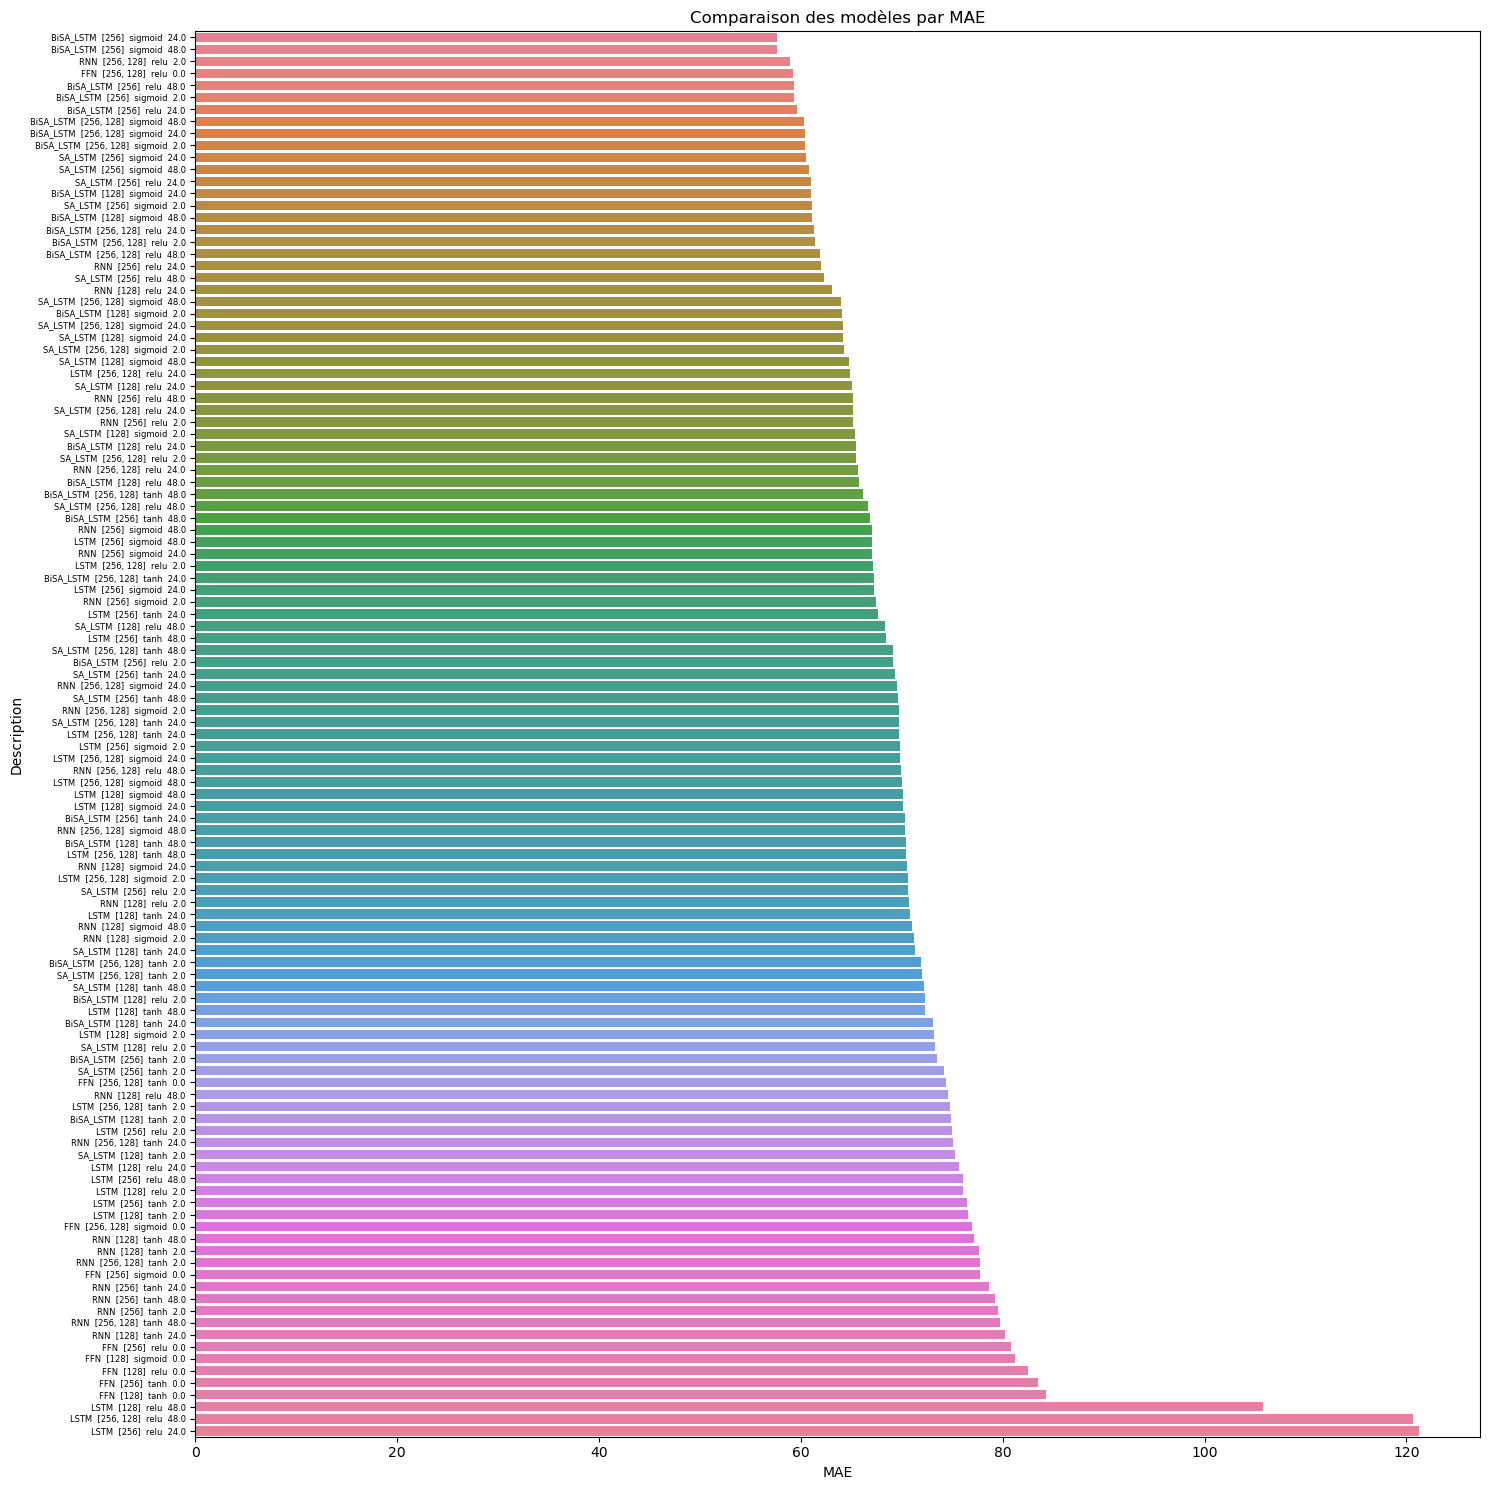

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.barplot(data=result,y="Description",x="MAE",palette='husl')
plt.yticks(fontsize=6)

# plt.legend(labels=result["Description"], title="Description", bbox_to_anchor=(1.05, 1),loc="upper left")

# Titre et labels
plt.title("Comparaison des modèles par MAE")
plt.xlabel("MAE")
plt.ylabel("Description")
plt.tight_layout()
plt.show()


### visualiser point des modeles
### visualiser meilleur modele
### amerliorer modele avec rolling windows
### visualiser ce qui explique le prix
### BiSA LSTM 256 sigmoid 24

In [91]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
import tensorflow as tf
from itertools import product
from sklearn.preprocessing import StandardScaler

In [92]:
df=pd.read_csv(r'INPUT.csv')
df['DateTime']=pd.to_datetime(df['DateTime'])
df['Date']=pd.to_datetime(df['Date'])
df['Minute']=df['Date'].dt.minute
df['Heure']=df['Date'].dt.hour
df['Jour']=df['DateTime'].dt.day
df['Mois']=df['DateTime'].dt.month
df['Annee']=df['DateTime'].dt.year
Y=pd.DataFrame(df['DateTime'])
df=df.drop(columns=['DateTime','Valeur','Date'])
df=df[['Heure','Minute','Jour','Mois','Annee']+[col for col in df.columns if col not in ['Heure','Minute','Jour','Mois','Annee']]]
df=df.fillna(0)
Y['MA']=df['MA']
X=df[[col for col in df.columns if col!='MA']]
scaler = StandardScaler()
X = scaler.fit_transform(X)  # Scale only X

C:\Users\adamh\AppData\Local\Temp\ipykernel_17608\3566987095.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date']=pd.to_datetime(df['Date'])


In [93]:
df.head()

,Heure,Minute,Jour,Mois,Annee,SPOT,MA,BIOMASS,FOSSIL_GAS,FOSSIL_HARD_COAL,FOSSIL_OIL,HYDRO_PUMPED_STORAGE,HYDRO_RUN_OF_RIVER,HYDRO_WATER_RESERVOIR,NUCLEAR,SOLAR,WASTE,WIND_ONSHORE,conso
0,0,0,1,1,2024,19.49,197.27,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,52800.0
1,0,30,1,1,2024,19.49,206.63,171.5,905.0,7.5,81.0,-1016.5,2411.0,740.5,20193.5,112.5,43.5,7199.5,53000.0
2,1,0,1,1,2024,16.12,23.62,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,47200.0
3,1,30,1,1,2024,16.12,56.66,171.5,920.0,8.0,95.5,-1033.5,2383.5,641.0,18764.0,0.0,41.5,7078.5,48100.0
4,2,0,1,1,2024,0.06,10.68,171.5,893.5,8.0,95.0,-842.5,2459.0,502.5,18660.0,0.0,43.5,6894.5,49800.0


In [94]:
def create_sequences(X, Y, timesteps):
    X_seq, Y_seq = [], []
    for i in range(timesteps, len(X)):
        X_seq.append(X[i-timesteps:i])
        Y_seq.append(Y[i])
    return np.array(X_seq), np.array(Y_seq)

In [95]:
def create_rnn_network_model(input_dim,
                              timesteps,
                              hidden_layers_sizes,
                              layers_activation,
                              output_dim,
                              output_activation):

    nb_hidden_layers = len(hidden_layers_sizes)
    inputs = tf.keras.Input(shape=(timesteps, input_dim))
    for n in range(nb_hidden_layers):
        return_seq = n < nb_hidden_layers - 1
        if n == 0:
            layer_output = tf.keras.layers.SimpleRNN(hidden_layers_sizes[n],
                                                     activation=layers_activation,
                                                     return_sequences=return_seq)(inputs)
        else:
            layer_output = tf.keras.layers.SimpleRNN(hidden_layers_sizes[n],
                                                     activation=layers_activation,
                                                     return_sequences=return_seq)(layer_output)
    outputs = tf.keras.layers.Dense(output_dim, activation=output_activation)(layer_output)
    rnn_model = tf.keras.Model(inputs, outputs, name='rnn_network')
    return rnn_model


In [96]:
def create_bisa_lstm_network_model(input_dim,
                                   timesteps,
                                   hidden_layers_sizes,
                                   layers_activation,
                                   output_dim,
                                   output_activation):

    nb_hidden_layers = len(hidden_layers_sizes)
    inputs = tf.keras.Input(shape=(timesteps, input_dim))

    for n in range(nb_hidden_layers):
        return_seq = True  # Required for attention
        if n == 0:
            layer_output = tf.keras.layers.Bidirectional(
                tf.keras.layers.LSTM(hidden_layers_sizes[n],
                                     activation=layers_activation,
                                     return_sequences=return_seq)
            )(inputs)
        else:
            layer_output = tf.keras.layers.Bidirectional(
                tf.keras.layers.LSTM(hidden_layers_sizes[n],
                                     activation=layers_activation,
                                     return_sequences=return_seq)
            )(layer_output)

    # Self-Attention
    attention = tf.keras.layers.Attention()([layer_output, layer_output])
    attention = tf.keras.layers.LayerNormalization()(attention)

    pooled_output = tf.keras.layers.GlobalAveragePooling1D()(attention)

    outputs = tf.keras.layers.Dense(output_dim, activation=output_activation)(pooled_output)

    bisa_lstm_model = tf.keras.Model(inputs, outputs, name='bisa_lstm_network')
    return bisa_lstm_model


In [97]:
from itertools import product
from sklearn.preprocessing import StandardScaler

y_scaler = StandardScaler()
Y_scaled = y_scaler.fit_transform(Y[['MA']])


model_builders = {
    # 'RNN': create_rnn_network_model,
    # 'LSTM': create_lstm_network_model,
    # 'SA_LSTM': create_sa_lstm_network_model,
    'BiSA_LSTM': create_bisa_lstm_network_model,
}

# Grille de recherche
hidden_layers_options = [[256]]
activation_functions = ['sigmoid']
timesteps_options = [24]

# results = []
tscv = TimeSeriesSplit(n_splits=5)
output_dim = 1
output_activation = 'linear'

for model_name, model_fn in model_builders.items():
    for hidden_layers_sizes, activation, timesteps in product(hidden_layers_options, activation_functions, timesteps_options):
        print(f"Testing {model_name} | Layers: {hidden_layers_sizes} | Activation: {activation} | Timesteps: {timesteps}")

        # Préparer les séquences
        X_seq, y_seq = create_sequences(X, Y_scaled, timesteps)

        fold_mae = []
        fold_r2=[]
        for train_idx, val_idx in tscv.split(X_seq):
            x_train, x_val = X_seq[train_idx], X_seq[val_idx]
            y_train, y_val = y_seq[train_idx], y_seq[val_idx]

            model = model_fn(
                input_dim=X_seq.shape[2],
                timesteps=timesteps,
                hidden_layers_sizes=hidden_layers_sizes,
                layers_activation=activation,
                output_dim=output_dim,
                output_activation=output_activation
            )

            model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                          loss='mae',
                          metrics=['mae'])

            model.fit(x_train, y_train, epochs=100, batch_size=16, verbose=0,
                      validation_data=(x_val, y_val), shuffle=False)

            y_pred = model.predict(x_val)
            mae = mean_absolute_error(y_val, y_pred)
            r2=r2_score(y_val,y_pred)
            fold_mae.append(mae)
            fold_r2.append(r2)

        avg_mae = np.mean(fold_mae)
        avg_r2=np.mean(fold_r2)
        print(f"→ Avg MAE: {avg_mae:.4f}")
        # results.append([model_name, hidden_layers_sizes, activation, timesteps, avg_mae,avg_r2])
# columns = ["Model", "Hidden Layers", "Activation", "Timesteps", "MAE", "R2"]
# df_results_nn = pd.DataFrame(results, columns=columns)

Testing BiSA_LSTM | Layers: [256] | Activation: sigmoid | Timesteps: 24
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
→ Avg MAE: 0.6584


In [107]:
Y1_scaled=model.predict(X_seq)

548/548 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step


In [108]:
Y1 = y_scaler.inverse_transform(Y1_scaled)

In [109]:
import numpy as np
for i in range (0,timesteps_options[0]):
    Y1 = np.insert(Y1, 0, np.nan)

In [110]:
Y['BisaLSTM_256_sigmoid_24']=Y1

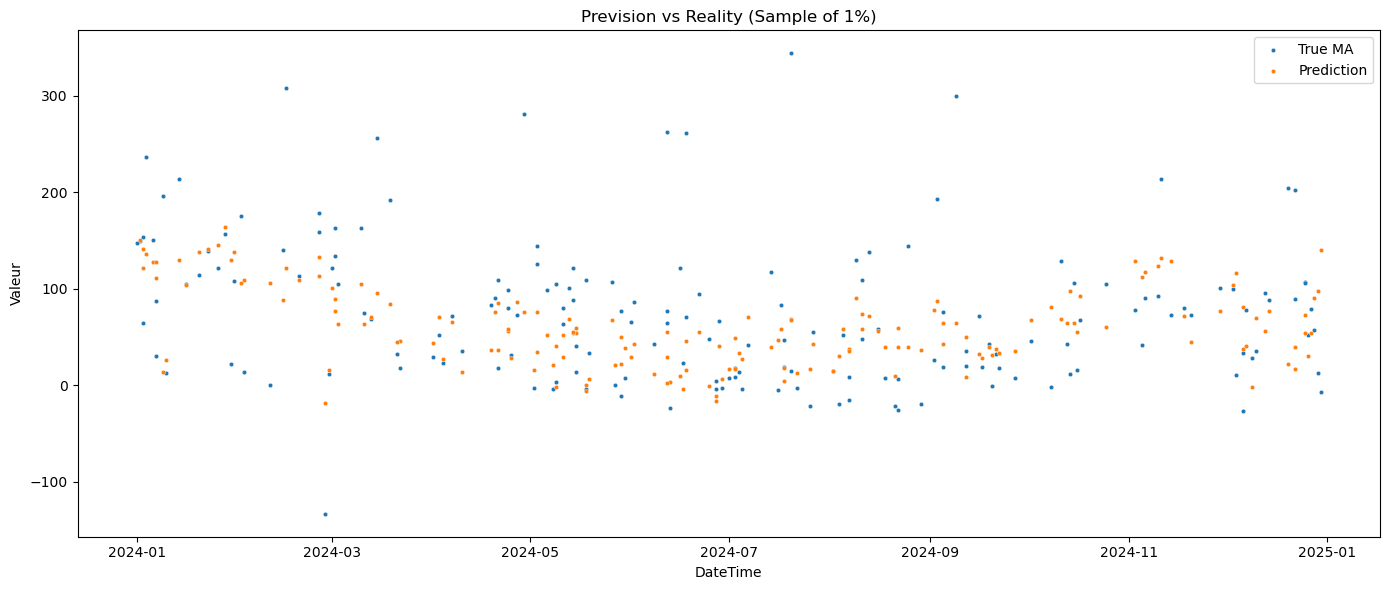

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

# Échantillonner 10 % des lignes de Y
Y_sample = Y.sample(frac=0.01, random_state=42)  # random_state pour reproductibilité

plt.figure(figsize=(14, 6))
sns.scatterplot(data=Y_sample, x="DateTime", y="MA", s=10, label="True MA")
sns.scatterplot(data=Y_sample, x="DateTime", y="BisaLSTM_256_sigmoid_24", s=10, label="Prediction")

plt.legend()
plt.title("Prevision vs Reality (Sample of 1%)")
plt.xlabel("DateTime")
plt.ylabel("Valeur")
plt.tight_layout()
plt.show()


In [183]:
Y24=Y.iloc[24:,:]
mae_base=mean_absolute_error(list(Y24['MA']), list(Y24['BisaLSTM_256_sigmoid_24']))
Y24.head()

,DateTime,MA,BisaLSTM_256_sigmoid_24
24,2024-01-01,143.79,118.732903
25,2024-01-01,125.15,120.704933
26,2024-01-01,151.61,119.009293
27,2024-01-01,475.83,120.928612
28,2024-01-01,64.55,118.817032


In [187]:
mae_base

56.405508499490146

In [189]:
from sklearn.metrics import mean_squared_error, r2_score

r2_base = r2_score(Y24['MA'], Y24['BisaLSTM_256_sigmoid_24'])
r2_base

0.03560973314511573

In [191]:
rmse_base = np.sqrt(mean_squared_error(Y24['MA'], Y24['BisaLSTM_256_sigmoid_24']))
rmse_base


110.03006843312012

In [144]:
X_seq.shape[2]
importances = []
n_features = X_seq.shape[2]
rng = np.random.default_rng(42)

In [147]:
# 1) Liste des features dans le même ordre que X
feature_names = [c for c in df.columns if c != 'MA']   # ou exactement l’ordre que tu as utilisé pour construire X

# 2) … ton code permutation importance …
importances = []  # liste des deltas
for j in range(n_features):
    X_permuted = X_seq.copy()
    shuffled = X_permuted[:, :, j].copy()
    rng.shuffle(shuffled, axis=0)
    X_permuted[:, :, j] = shuffled

    y_pred_perm = model.predict(X_permuted, verbose=0)
    mae_perm = mean_absolute_error(y_seq, y_pred_perm)
    delta = mae_perm - mae_base
    importances.append(delta)

# 3) Associer importances ↔ noms de features
importances = np.array(importances)
ranking = np.argsort(importances)[::-1]

# Tableau trié (simple et clair)
feat_imp = pd.DataFrame({
    'feature': np.array(feature_names)[ranking],
    'delta_mae': importances[ranking]
})
print(feat_imp.head(20))  # top 20


                  feature  delta_mae
0                    Mois -55.846196
1                   WASTE -55.867011
2                   SOLAR -55.878238
3    HYDRO_PUMPED_STORAGE -55.887774
4                   Heure -55.888819
5   HYDRO_WATER_RESERVOIR -55.892720
6                 BIOMASS -55.893699
7            WIND_ONSHORE -55.894709
8                 NUCLEAR -55.894781
9                   conso -55.895031
10             FOSSIL_GAS -55.895714
11       FOSSIL_HARD_COAL -55.896007
12     HYDRO_RUN_OF_RIVER -55.896457
13                   SPOT -55.897104
14             FOSSIL_OIL -55.897573
15                   Jour -55.898266
16                 Minute -55.900001
17                  Annee -55.901871


In [149]:
from sklearn.metrics import r2_score

# y_true = vraies valeurs
# y_pred = valeurs prédites par ton modèle
mae_base=r2_score(list(Y24['MA']), list(Y24['BisaLSTM_256_sigmoid_24']))

print(f"R² = {r2:.4f}")

R² = -0.6924


Voyons pourquoi R2 negatif

Testing RNN | Layers: [256] | Activation: sigmoid | Timesteps: 24


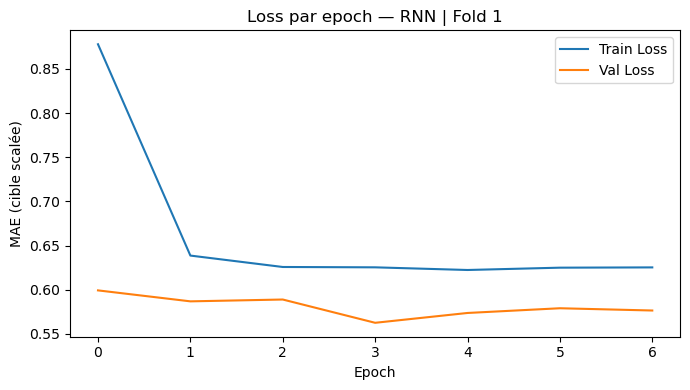

Fold 1 → MAE: 63.0167 | R²: -0.0118


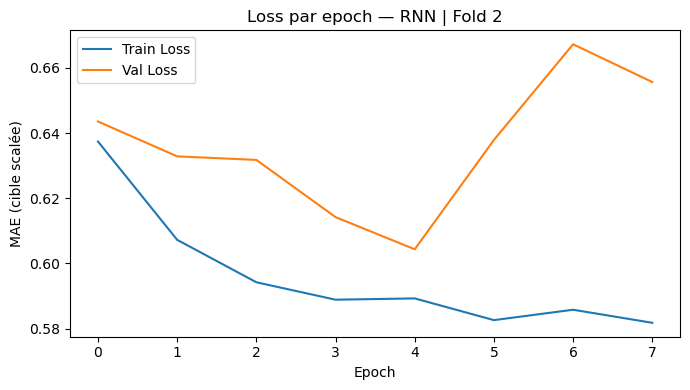

Fold 2 → MAE: 67.6839 | R²: -0.0395


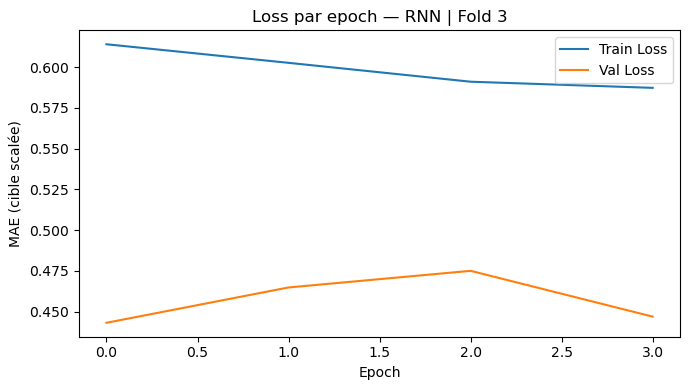

Fold 3 → MAE: 49.6414 | R²: 0.0085


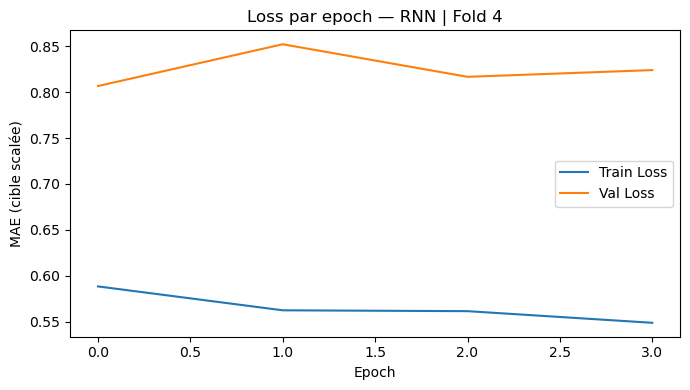

Fold 4 → MAE: 90.3334 | R²: -0.5517


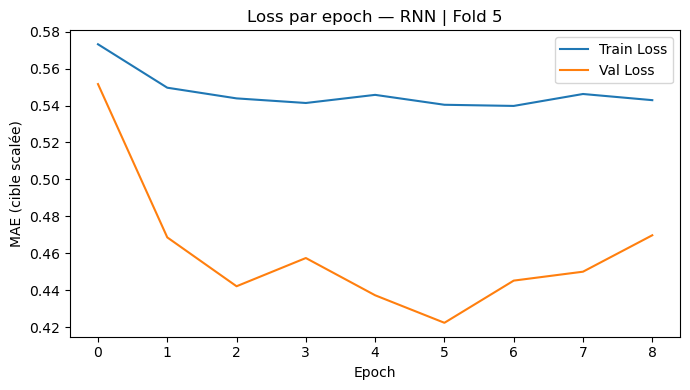

Fold 5 → MAE: 47.3165 | R²: -0.2109

→ Moyennes (RNN): MAE=63.5984 | R²=-0.1611



In [193]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

model_builders = {
    'RNN': create_bisa_lstm_network_model,
}

hidden_layers_options = [[256]]
activation_functions = ['sigmoid']
timesteps_options = [24]

tscv = TimeSeriesSplit(n_splits=5)
output_dim = 1
output_activation = 'linear'

for model_name, model_fn in model_builders.items():
    for hidden_layers_sizes, activation, timesteps in product(hidden_layers_options, activation_functions, timesteps_options):
        print(f"Testing {model_name} | Layers: {hidden_layers_sizes} | Activation: {activation} | Timesteps: {timesteps}")

        # Séquences (et s'assure que y est bien 2D: (n,1))
        X_seq, y_seq = create_sequences(X, Y_scaled, timesteps)
        y_seq = np.array(y_seq).reshape(-1, 1)

        fold_mae, fold_r2 = [], []

        for fold_id, (train_idx, val_idx) in enumerate(tscv.split(X_seq), start=1):
            x_train, x_val = X_seq[train_idx], X_seq[val_idx]
            y_train, y_val = y_seq[train_idx], y_seq[val_idx]

            model = model_fn(
                input_dim=X_seq.shape[2],
                timesteps=timesteps,
                hidden_layers_sizes=hidden_layers_sizes,
                layers_activation=activation,
                output_dim=output_dim,
                output_activation=output_activation
            )

            model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                loss='mae',
                metrics=['mae']
            )

            # Early stopping pour gagner du temps
            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=3,
                restore_best_weights=True
            )

            # Entraînement + historique
            history = model.fit(
                x_train, y_train,
                epochs=100,
                batch_size=32,
                validation_data=(x_val, y_val),
                shuffle=False,
                callbacks=[early_stop],
                verbose=0
            )

            # Courbe de perte pour ce fold
            plt.figure(figsize=(7,4))
            plt.plot(history.history['loss'], label='Train Loss')
            plt.plot(history.history['val_loss'], label='Val Loss')
            plt.title(f'Loss par epoch — {model_name} | Fold {fold_id}')
            plt.xlabel('Epoch'); plt.ylabel('MAE (cible scalée)')
            plt.legend(); plt.tight_layout(); plt.show()

            # Prédictions
            y_pred = model.predict(x_val, verbose=0).reshape(-1, 1)

            # Inverse scaling pour métriques lisibles
            y_pred_inv = y_scaler.inverse_transform(y_pred).ravel()
            y_val_inv  = y_scaler.inverse_transform(y_val).ravel()

            mae = mean_absolute_error(y_val_inv, y_pred_inv)
            r2  = r2_score(y_val_inv, y_pred_inv)
            fold_mae.append(mae)
            fold_r2.append(r2)

            print(f"Fold {fold_id} → MAE: {mae:.4f} | R²: {r2:.4f}")

        avg_mae = np.mean(fold_mae)
        avg_r2  = np.mean(fold_r2)
        print(f"\n→ Moyennes ({model_name}): MAE={avg_mae:.4f} | R²={avg_r2:.4f}\n")
